# Demo - Train the basic autoencoder using the Fashon MNIST dataset. Each image in this dataset is 28x28 pixels.

In [1]:
#Copyright The TensorFlow Authors.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

## Task 01: Basic Autoencoder Implementation

### Step 1: Load and Prepare the Dataset

In [2]:
# [TODO]: Load the Fashon MNIST dataset.
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# [TODO]: Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# [TODO]: Print shapes to verify dimensions
print (x_train.shape)
print (x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


### Step 2: Define the Autoencoder Model
We'll create an autoencoder with two main components:
- An encoder that will learn to compresse images from 784 dimensions (28×28 pixel images flattened) down to the 64-dimensional latent vector
- A decoder that will learn to reconstruct the original 28×28 pixel image from this latent representation

In [3]:
# [TODO]: Define the latent dimension
latent_dim = 64

# [TODO]: Create the autoencoder model class that inherits from Keras Model
class Autoencoder(Model):
  def __init__(self, latent_dim):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim
    self.encoder = tf.keras.Sequential([
      layers.Flatten(),
      layers.Dense(latent_dim, activation='relu'),
    ])
    self.decoder = tf.keras.Sequential([
      layers.Dense(784, activation='sigmoid'),
      layers.Reshape((28, 28))
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

### Step 3: Compile and Train the Model
Now, let's instantiate our autoencoder model, compile it with an appropriate loss function, and train it.

In [4]:
# [TODO]: Create the autoencoder model
autoencoder = Autoencoder(latent_dim)

In [5]:
# [TODO]: Compile the model
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

In [6]:
# [TODO]: Train the model
# Notice we use x_train as both the input and the target. 
autoencoder.fit(x_train, x_train,
                epochs=10,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0400 - val_loss: 0.0135
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0123 - val_loss: 0.0107
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0103 - val_loss: 0.0098
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0096 - val_loss: 0.0093
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0092 - val_loss: 0.0092
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0090 - val_loss: 0.0090
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0089 - val_loss: 0.0090
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0088 - val_loss: 0.0088
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0087 - val_loss: 0.0090
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0087 - val_loss: 0.0088


### Step 4: Evaluate and Visualize the Results
Now model is trained, let's test it by encoding and decoding images from the test set.

In [7]:
# [TODO]: Encode and decode test images
encoded_imgs = autoencoder.encoder(x_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

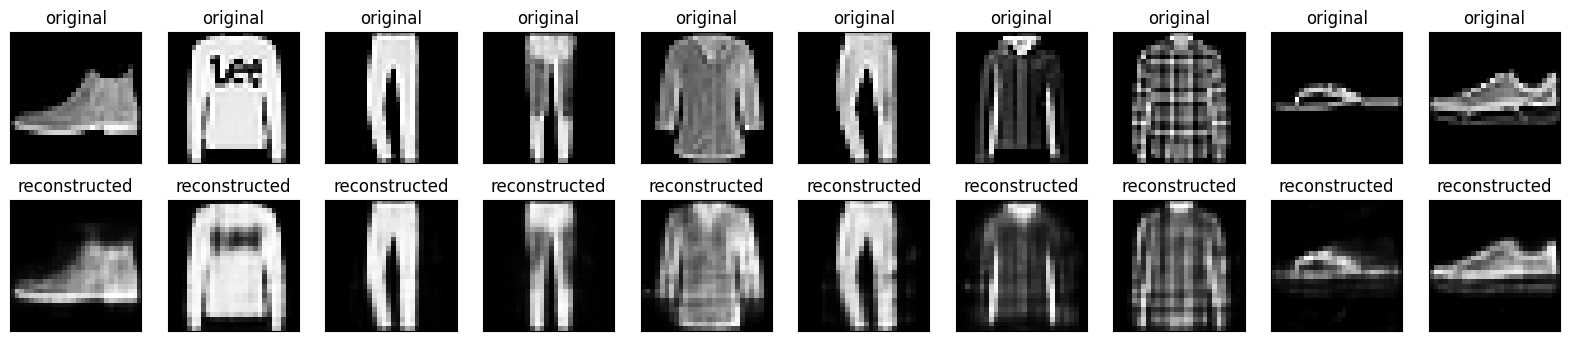

In [8]:
# [TODO]: Plot 10 images with original vs reconstructed images
n = 10 #10 images to plot
plt.figure(figsize=(20, 4))
for i in range(n):
  # display original
  ax = plt.subplot(2, n, i + 1)
  plt.imshow(x_test[i])
  plt.title("original")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # display reconstruction
  ax = plt.subplot(2, n, i + 1 + n)
  plt.imshow(decoded_imgs[i])
  plt.title("reconstructed")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

## Task 02: Image Denoising
In this section, we'll create a noisy version of the Fashion MNIST dataset by applying random noise to each image.

In [9]:
# [TODO]: Reimport the dataset to omit the modifications made earlier.
(x_train, _), (x_test, _) = fashion_mnist.load_data()

In [10]:
# [TODO]: Normalize and reshape to include channel dimension
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(x_train.shape)

(60000, 28, 28, 1)


In [11]:
# [TODO]: Adding random noise to the images
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

# [TODO]: Clip the values to be between 0 and 1

x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

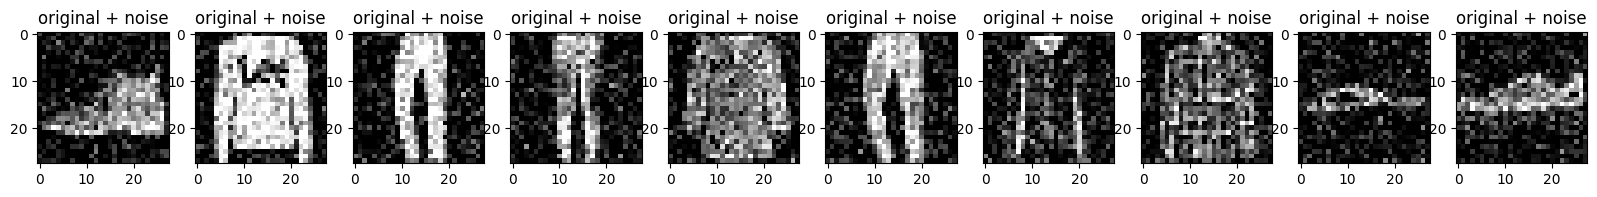

In [12]:
# [TODO]: Plot 10 noisy images.
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
plt.show()